<font size="5.8">--</font>  


Python functions and data files needed to run this notebook are available via this [link](https://github.com/MehdiRezvandehy/agentic_workflow_crewai_langchain.git).

<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Using-MCP-to-Enhance-Agent-Capabilities" data-toc-modified-id="Using-MCP-to-Enhance-Agent-Capabilities-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Using MCP to Enhance Agent Capabilities</a></span></li><li><span><a href="#LangGraph-Specific-Setup" data-toc-modified-id="LangGraph-Specific-Setup-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>LangGraph-Specific Setup</a></span></li><li><span><a href="#Incorporating-MCP-into-the-architecture" data-toc-modified-id="Incorporating-MCP-into-the-architecture-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Incorporating MCP into the architecture</a></span></li><li><span><a href="#Local-MCP-Server-Using-stdio" data-toc-modified-id="Local-MCP-Server-Using-stdio-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Local MCP Server Using <code>stdio</code></a></span><ul class="toc-item"><li><span><a href="#Exmaple-1" data-toc-modified-id="Exmaple-1-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>Exmaple 1</a></span></li><li><span><a href="#Exmaple-2" data-toc-modified-id="Exmaple-2-4.2"><span class="toc-item-num">4.2&nbsp;&nbsp;</span>Exmaple 2</a></span></li></ul></li><li><span><a href="#MCP-Server-Using-Streamable-HTTP" data-toc-modified-id="MCP-Server-Using-Streamable-HTTP-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>MCP Server Using Streamable HTTP</a></span><ul class="toc-item"><li><span><a href="#Example-1-with-Streamable-HTTP" data-toc-modified-id="Example-1-with-Streamable-HTTP-5.1"><span class="toc-item-num">5.1&nbsp;&nbsp;</span>Example 1 with Streamable HTTP</a></span></li></ul></li><li><span><a href="#Remote-MCP-Server" data-toc-modified-id="Remote-MCP-Server-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Remote MCP Server</a></span><ul class="toc-item"><li><span><a href="#Example-:-DeepWiki-MCP-Server" data-toc-modified-id="Example-:-DeepWiki-MCP-Server-6.1"><span class="toc-item-num">6.1&nbsp;&nbsp;</span>Example : DeepWiki MCP Server</a></span></li></ul></li><li><span><a href="#📚-Document-Intelligence-App:-MCP,-RAG,-and-AI-Agents" data-toc-modified-id="📚-Document-Intelligence-App:-MCP,-RAG,-and-AI-Agents-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>📚 Document Intelligence App: MCP, RAG, and AI Agents</a></span><ul class="toc-item"><li><span><a href="#🔍-Local-MCP-—-Drive-Search" data-toc-modified-id="🔍-Local-MCP-—-Drive-Search-7.1"><span class="toc-item-num">7.1&nbsp;&nbsp;</span>🔍 <strong>Local MCP — Drive Search</strong></a></span></li><li><span><a href="#🤖-Local-RAG-for-Document-Question-Answering" data-toc-modified-id="🤖-Local-RAG-for-Document-Question-Answering-7.2"><span class="toc-item-num">7.2&nbsp;&nbsp;</span>🤖 <strong>Local RAG for Document Question Answering</strong></a></span></li><li><span><a href="#🌐-Remote-MCP-Agent" data-toc-modified-id="🌐-Remote-MCP-Agent-7.3"><span class="toc-item-num">7.3&nbsp;&nbsp;</span>🌐 <strong>Remote MCP Agent</strong></a></span></li><li><span><a href="#Implementation" data-toc-modified-id="Implementation-7.4"><span class="toc-item-num">7.4&nbsp;&nbsp;</span>Implementation</a></span><ul class="toc-item"><li><span><a href="#document_search_mcp.py" data-toc-modified-id="document_search_mcp.py-7.4.1"><span class="toc-item-num">7.4.1&nbsp;&nbsp;</span><code>document_search_mcp.py</code></a></span></li><li><span><a href="#Dockerfile.mcp" data-toc-modified-id="Dockerfile.mcp-7.4.2"><span class="toc-item-num">7.4.2&nbsp;&nbsp;</span>Dockerfile.mcp</a></span></li></ul></li><li><span><a href="#🔍-Local-MCP-—-Drive-Search" data-toc-modified-id="🔍-Local-MCP-—-Drive-Search-7.5"><span class="toc-item-num">7.5&nbsp;&nbsp;</span>🔍 Local MCP — Drive Search</a></span></li><li><span><a href="#🤖-Local-RAG-—-Document-Question-Answering" data-toc-modified-id="🤖-Local-RAG-—-Document-Question-Answering-7.6"><span class="toc-item-num">7.6&nbsp;&nbsp;</span>🤖 Local RAG — Document Question Answering</a></span></li><li><span><a href="#🌐-Remote-MCP-Agent" data-toc-modified-id="🌐-Remote-MCP-Agent-7.7"><span class="toc-item-num">7.7&nbsp;&nbsp;</span>🌐 Remote MCP Agent</a></span></li></ul></li><li><span><a href="#Summary" data-toc-modified-id="Summary-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>Summary</a></span><ul class="toc-item"><li><span><a href="#Risk-Using-MCP" data-toc-modified-id="Risk-Using-MCP-8.1"><span class="toc-item-num">8.1&nbsp;&nbsp;</span>Risk Using MCP</a></span></li></ul></li></ul></div>

# Using MCP to Enhance Agent Capabilities

**Model Context Protocol (MCP)** invented by **Antropic** in November 2024, it grows until 2025 around the concept of standardizing of the way we pass information to LLM. MCP is an open standard designed to bridge AI agents with the world of data and tools, to plug in many different sources of context as making tools is pretty ad-hoc so developers write custom code or use specialized plugins for each data source or API.

MCP is not itself, code, framework or LLM, it is a set of rules that we are would agree to provide a resource and creat a **server** that itself holds context for LLM. Broadly speaking, MCP is valuable when you want **an LLM to interact with external systems**, either by accessing information beyond its training data or by taking actions on your behalf.

The image below compares AI architectures before and after the Model Context Protocol (MCP). Before MCP, LLMs needed separate custom integrations for every tool. With MCP, the LLM connects through a single unified interface, while MCP handles communication with external tools. This simplifies integration, improves scalability, and standardizes connectivity across AI systems.

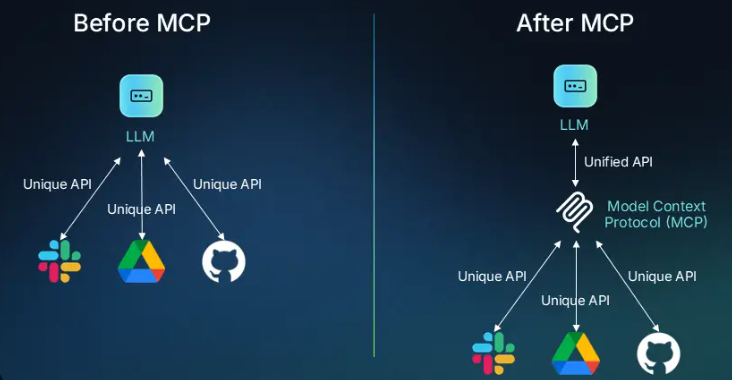
Source: https://mcpshowcase.com/blog/what-is-mcp

MCP provides three main components for LLMs: **Tools, Resources, and Prompts**. However, most attention is usually given to **Tools**, which define a standard way to build and share capabilities across systems. Infact, the MCP is a starndardized way of creating and writing tools so that we can share with each other different MCP access to tools

A simple example: Person A builds an **MCP server** that exposes certain APIs as tools. They package it with required environment variables (like API keys) and open-source it. Now anyone—Person B, C, D, and others—can plug into this MCP server and instantly gain access to those tools without rebuilding the integration themselves: **MCP enables reusable, shareable tool access where one provider can expose capabilities and many consumers can easily use them.**

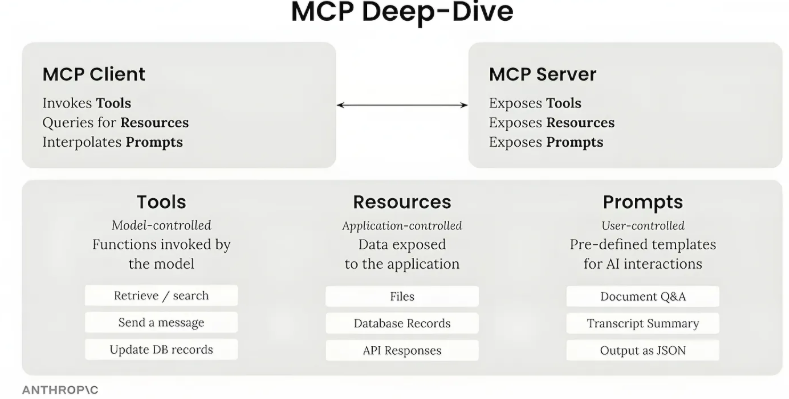
https://ppaolo.substack.com/p/how-anthropics-mcp-outshined-openais

The MCP is designed to solve the **M×N integration problem**, where connecting *M* AI models to *N* tools or data sources would otherwise require a large number of custom integrations. Without a common standard, developers must create and maintain separate connectors for each model–tool combination, leading to significant complexity and maintenance overhead. MCP introduces a **universal communication protocol** that acts as a common interface between AI applications and external systems. As a result, any MCP-compatible AI application—such as an IDE, chatbot, or agent platform—can interact with any MCP-compliant tool, database, or service without additional custom development. This standardization improves interoperability, reduces engineering effort, simplifies system integration, and enables AI ecosystems to scale more efficiently.

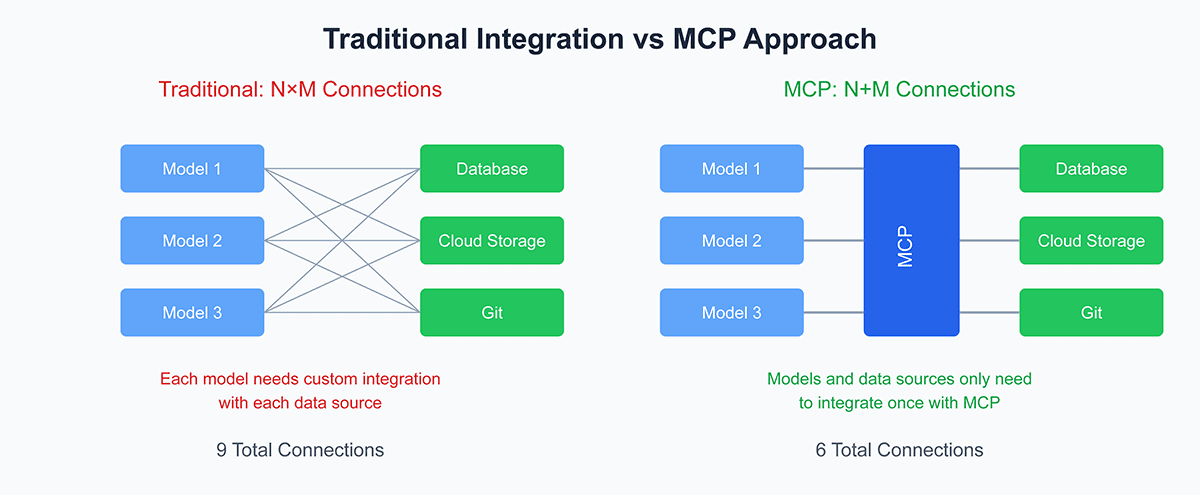
Source: https://humanloop.com/blog/mcp

Extending this idea, an **MCP server** is responsible for providing functionality by connecting to **external tools** and **data sources**, while an **MCP client** is what consumes and interacts with those capabilities through a user interface or application layer.

For example, we can use **Streamlit**, a lightweight Python framework for building interactive web apps, to quickly create an **MCP client** UI. This allows us to focus on connecting to **remote MCP servers** and exploring different AI capabilities, while Streamlit handles the interface with minimal setup and fast prototyping.

A working MCP server can be very simple. Here, the **FastMCP** server is essentially a FastAPI-based server designed specifically for MCP resources, prompts, and tools. 

The code below shows a simple end-to-end functional MCP example. It is basically a **FastAPI server** built specifically for MCP resources, prompts and tools.

In [2]:
from mcp.server.fastmcp import FastMCP

mcp = FastMCP("MCP Simple Example")

@mcp.tool()
def add_numbers(a: int, b: int) -> int:
    return a + b

# Show registered tools
print(mcp._tool_manager.list_tools())

[Tool(fn=<function add_numbers at 0x000001B81C5D7600>, name='add_numbers', title=None, description='', parameters={'properties': {'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}, 'required': ['a', 'b'], 'title': 'add_numbersArguments', 'type': 'object'}, fn_metadata=FuncMetadata(arg_model=<class 'mcp.server.fastmcp.utilities.func_metadata.add_numbersArguments'>, output_schema={'properties': {'result': {'title': 'Result', 'type': 'integer'}}, 'required': ['result'], 'title': 'add_numbersOutput', 'type': 'object'}, output_model=<class 'mcp.server.fastmcp.utilities.func_metadata.add_numbersOutput'>, wrap_output=True), is_async=False, context_kwarg=None, annotations=None, icons=None, meta=None)]


Companies are building MCP servers for their own platforms — *Notion* has one, *Zapier* has one, and there are also several third-party MCP servers for *Salesforce*. This shows that building MCP servers is not limited to the companies that own the systems; developers and the broader community can build them as well.

For example, *Zapier* MCP lets your AI agent connect to thousands of apps through a standardized MCP interface. Instead of building separate integrations for each service, the AI simply uses Zapier’s MCP layer to access tools like email, messaging, spreadsheets, and CRMs in a unified way.

Briefly, the workflow is:

1. **Create a Zapier MCP server**:
   Zapier exposes actions from apps like Gmail, Slack, Google Sheets, and Notion as MCP tools.

2. **Connect the MCP server to your AI agent**:
   Your LLM application (for example using LangChain, LangGraph, or a custom agent) connects to the Zapier MCP endpoint.

3. **The AI discovers available tools automatically**:
   The agent can see available actions such as:

   * Send email
   * Create calendar event
   * Update spreadsheet
   * Post Slack message

4. **The AI calls tools when needed**:
   Example:

   * User says: “Send meeting notes to the team.”
   * AI decides to use Gmail + Slack tools through Zapier MCP.
   * Zapier executes the actions securely.

**This removes the need to manually build separate API integrations for every app.**

The sections below demonstrate how to use MCP servers with LangGraph agents, covering both local and remote MCP server configurations.

# LangGraph-Specific Setup

To make this concrete, let’s walk through a simple example of running an MCP-style tool integration in LangGraph and see how an agent can be granted access to external tools in practice.

In [3]:
# A way to get a tool from langchain
from langchain_community.agent_toolkits.load_tools import load_tools
# Core LLM interface (OpenAI chat models)
from langchain_openai import ChatOpenAI
from rich.markdown import Markdown
import os
from dotenv import load_dotenv
load_dotenv(override=True)
    
# Read API key from environment variable
os.environ["SERPAPI_API_KEY"] = os.getenv("SERP_API_KEY")  # https://serpapi.com for a free token!
# LLM Model
os.environ['OPENAI_API_KEY'] = os.environ.get("OPENAI_API_KEY")
model = ChatOpenAI(model='gpt-4o-mini')

tools = load_tools(["serpapi"])

In [4]:
tools[0].run('Mehdi Rezvandehy')

'[\'Mehdi Rezvandehy. Mehdi Rezvandehy. Doctor of Philosophy in Mining Engineering Department of Civil and Environmental Engineering University of Alberta © Mehdi ...\', \'Mehdi Rezvandehy Mehdi. The exploitation of hydrocarbon reservoirs may potentially lead to contamination of soils, shallow water resources, and greenhouse gas ...\', "Mehdi Rezvandehy, PhD — Orchestrating Multi-Agent AI Systems with LangGraph Whether you\'re into AI, MLOps, or just want to connect with Calgary ...", \'Rezvandehy, Mehdi. Institution. University of Alberta. Degree Level. Doctoral. Degree. Doctor of Philosophy. Department. Department of Civil and Environmental ...\', "Org chart ; Mehdi Rezvandehy\'s profile picture. Mehdi Rezvandehy. Principal Data Scientist ; Kelly Keenan\'s profile picture. Kelly Keenan. Principal Data ...", \'Mehdi Rezvandehy, B. Mayer. 2023, Data-Centric Engineering. Sevenfold Underestimation of Methane Emissions from Non-producing Oil and Gas Wells in Canada.\', \'Mehdi RezvandehyJ

In [4]:
# Use MemorySaver to save short term memory agent
from langgraph.checkpoint.memory import MemorySaver

# Prebuilt ReAct-style agent + state injection utilities
from langgraph.prebuilt import InjectedState, create_react_agent

agent_executor = create_react_agent(model, 
                                    tools, 
                                    checkpointer=MemorySaver())

C:\Users\mrezv\AppData\Local\Temp\ipykernel_16848\4096780630.py:7: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent_executor = create_react_agent(model,


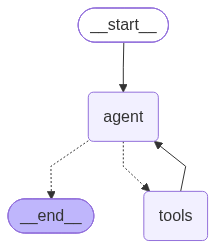

In [5]:
# Compile the graph
from IPython.display import Image, display

display(Image(agent_executor.get_graph().draw_mermaid_png()))

In [6]:
query = "Who is Mehdi Rezvandehy, where does he work and what is his background."

response = agent_executor.invoke({"messages": [{"role": "user","content": query}]},
    config={"configurable": {"thread_id": "demo"}})

[09/21/26 20:57:01] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=454840;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=936251;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1038\1038]8;;\
                             "HTTP/1.1 200 OK"                                                                     

[09/21/26 20:57:03] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=427259;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=413277;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1038\1038]8;;\
                             "HTTP/1.1 200 OK"                                                                     

[09/21/26 20:57:04] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=906297;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=464778;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1038\1038]8;;\
                             "HTTP/1.1 200 OK"                                                                     

[09/21/26 20:57:06] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=960190;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=828599;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1038\1038]8;;\
                             "HTTP/1.1 200 OK"                                                                     

[09/21/26 20:57:08] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=871037;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=758820;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1038\1038]8;;\
                             "HTTP/1.1 200 OK"                                                                     

[09/21/26 20:57:11] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=513326;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=725954;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1038\1038]8;;\
                             "HTTP/1.1 200 OK"                                                                     

In [7]:
Markdown(response["messages"][-1].content)

Mehdi Rezvandehy is a researcher and data scientist who currently works at the University of Calgary. He holds a   
PhD in Geostatistics from the University of Alberta and has extensive experience in various industries, including  
energy and finance.                                                                                                

His research focuses on integrating seismic attributes for accurate geological modeling and predicting serious     
fluid leakages, such as methane and carbon dioxide. Additionally, he has a background with previous roles at the   
Centre for Computational Geostatistics, Dana Energy, and National Iranian Oil Company, showcasing his expertise    
across different domains related to geoscience and data analysis.                                                  

For more detailed inquiries, you may reach out to him via his academic email at the University of Calgary.

# Incorporating MCP into the architecture

One important caveat is that MCP implementation depends on the client you're using. For example, Claude Desktop supports MCP, and Cursor, an AI-powered development environment, also supports MCP. Each client has its own approach to configuring and interacting with MCP, as described in its documentation.

In this example, I'll demonstrate how to **build a LangGraph agent that connects to an MCP server**. This is the approach recommended by the LangGraph documentation and is the method we'll use throughout this guide. Keep in mind that other MCP clients may follow different implementation patterns, so this is not a universal setup.


An MCP server can run either:

1. **Locally** on your machine
2. **Remotely** on another server over HTTP

The AI agent does not really care where the MCP server is running. It only cares about:

* Connecting to the server
* Discovering tools
* Calling tools

**A local MCP server runs on your own computer. The agent communicates directly with the local process.**

Usually via:

* Stdio (`from mcp.client.stdio import stdio_client`)
* Local HTTP (`http://localhost:8000/mcp`)

* **Advantages of Local MCP**
  * Faster
  * More secure
  * No internet required
  * Can access local files/databases
  * Easier for development

* **Example Local Use Cases**

  * Filesystem tools
  * Local PDFs
  * Private company data
  * Local databases
  * Local Python execution  
  

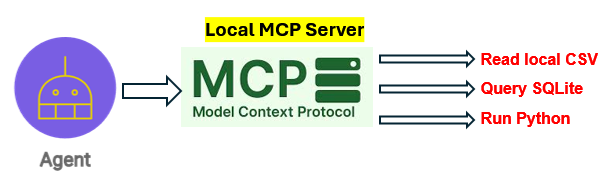

Here is an example of local server:
```python 
from mcp.client.stdio import stdio_client

async with stdio_client(server_params) as (
    read_stream,
    write_stream
)
```
This launches a local MCP process.

A remote MCP server runs somewhere else on the internet. For example, https://docs.devin.ai/work-with-devin/deepwiki-mcp is a remote MCP server.

* **Advantages of Remote MCP**
  * Shared by many users
  * Centralized tools
  * Easier deployment
  * Access cloud resources/APIs
  * No installation needed on client side

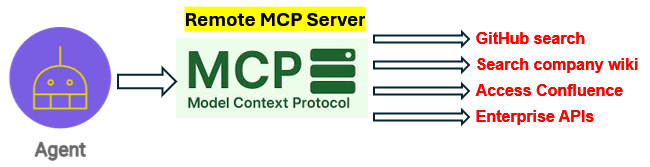

Here is an example of remote MCP server:
```python 
from mcp.client.streamable_http import streamablehttp_client

async with streamablehttp_client(
    "https://mcp.deepwiki.com/mcp"
)
```
**This connects to a remote MCP endpoint.**

Local MCP Server can be run using `stdio` and `Streamable HTTP`. See the examples below for details of each: 

# Local MCP Server Using `stdio`

In this example, I built a simple agent and show how it connects to a **local MCP server** using **stdio**. This is not a universal standard for all platforms—it's simply one implementation approach based on LangGraph’s documented way of integrating with MCP.

The MCP server communicates with the MCP client. It creates an MCP server that communicates through **stdio**. It is also possible to connect to an MCP server through **HTTP** I will cover on next section.

Here is example of local MCP server using stdio

```python
mcp = FastMCP("local-filesystem")

...

if __name__ == "__main__":
    mcp.run(transport="stdio")
```

This creates a Python MCP server process.

The important part is:

```python
mcp.run(transport="stdio")
```

It means:

> "Start the MCP server and communicate with the client through the process's **standard input/output**."

Conceptually:
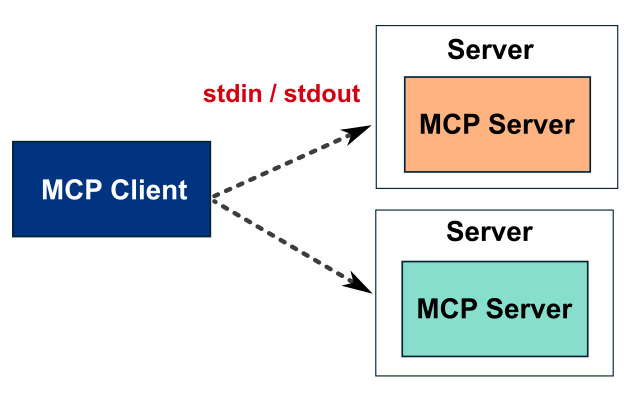

The client typically **starts the Python process itself**.

For example, conceptually the client configuration might say:

```json
{
  "command": "python",
  "args": ["mcp_server.py"]
}
```

Then the client launches:

```text
python mcp_server.py
```

and talks to that process through stdin/stdout.

So even though the server is "local", **stdio is the transport mechanism**, not the fact that it is local.

## Exmaple 1

Here is a simple MCP server, that is saved as `*.py` file as it is required for local MC server.

In [8]:
#!pip install langchain-mcp-adapters

In [9]:
# Import necessary libraries
from mcp import ClientSession, StdioServerParameters
from mcp.client.stdio import stdio_client
from langchain_mcp_adapters.tools import load_mcp_tools
from langchain.agents import create_agent

# Use nest_asyncio because of using this into jupyter notebook
import nest_asyncio

# Apply nest_asyncio to handle nested event loops
nest_asyncio.apply()

In [10]:
MCP_SERVER = f'''
from mcp.server.fastmcp import FastMCP
from langchain_community.utilities import SerpAPIWrapper
import os

mcp = FastMCP("Simple MCP Example")

# Register this function as a callable MCP tool.
@mcp.tool()
def multiply(a: float, b: float) -> int:
    """Multiply two float numbers"""
    return a * b

@mcp.tool()
def add(a: float, b: float) -> int:
    """Add two float numbers"""
    return a + b


@mcp.tool()
def google_search(query: str) -> str:
    """Apply Online Realtime Web Search"""
    serpapi = SerpAPIWrapper(serpapi_api_key="{os.getenv("SERP_API_KEY")}")
    return serpapi.run(query)

if __name__ == "__main__":
    mcp.run(transport="stdio")
'''

mcp_path = 'mcp_server_1.py'

with open(mcp_path, 'w') as f:
    f.write(MCP_SERVER)

print("Saved to:", os.path.abspath(mcp_path))

Saved to: D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agents_in_production\empower_agent_with_mcp_server\mcp_server_1.py


The code below sets up an asynchronous pipeline that connects to a local MCP server (`mcp_server_1.py`) using a stdio subprocess. It starts the server, creates a session, and initializes communication. Then it loads all tools exposed by the MCP server and prints their metadata. These tools are passed into a LangGraph ReAct agent built on a ChatOpenAI model. Finally, the agent is executed asynchronously with memory support to process the user’s input query. The memory support saves the conversation state so it can remember previous messages in the same thread.

In [11]:
import asyncio
import sys
import os

from langchain_openai import ChatOpenAI
from mcp import ClientSession, StdioServerParameters
from mcp.client.stdio import stdio_client
from langchain_mcp_adapters.tools import load_mcp_tools
from rich.markdown import Markdown

# Windows notebook asyncio fix
asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

# MCP server process config
server_params = StdioServerParameters(
    command=sys.executable,
    args=[os.path.abspath(mcp_path)]
)

# async means this function can run cooperatively with other tasks without blocking the program.
async def agent_run_async(m, thread_id="thread_id"):
    # RUN THE SERVER: Start MCP stdio connection, 
    async with stdio_client(server_params, errlog=None) as (read, write):

        # READ FROM THAT SESSION
        async with ClientSession(read, write) as session:

            # Initialize MCP connection
            await session.initialize()

            # Load MCP tools from that server into LangGraph
            mcp_tools = await load_mcp_tools(session)

            # Print discovered tools
            for tool in mcp_tools:
                print(f'Tool Name: {tool.name}')
                print(f'Tool Description: {tool.description}')
                print(f'Tool Arguments Schema: {tool.args_schema}')
                print(f'Tool Response Format: {tool.response_format}')
                print('-' * 40)

            # Create agent with MCP tools
            agent = create_agent(
                model,
                mcp_tools,
                checkpointer=MemorySaver()
            )

            # Run agent
            return await agent.ainvoke(
                {"messages": m},
                config={"configurable": {"thread_id": thread_id}}
            )

In [12]:
agent_response = await agent_run_async("What is current home price on average for a detached house in Calgary for August 2026 times 12?", thread_id='my test')

Tool Name: multiply
Tool Description: Multiply two float numbers
Tool Arguments Schema: {'properties': {'a': {'title': 'A', 'type': 'number'}, 'b': {'title': 'B', 'type': 'number'}}, 'required': ['a', 'b'], 'title': 'multiplyArguments', 'type': 'object'}
Tool Response Format: content_and_artifact
----------------------------------------
Tool Name: add
Tool Description: Add two float numbers
Tool Arguments Schema: {'properties': {'a': {'title': 'A', 'type': 'number'}, 'b': {'title': 'B', 'type': 'number'}}, 'required': ['a', 'b'], 'title': 'addArguments', 'type': 'object'}
Tool Response Format: content_and_artifact
----------------------------------------
Tool Name: google_search
Tool Description: Apply Online Realtime Web Search
Tool Arguments Schema: {'properties': {'query': {'title': 'Query', 'type': 'string'}}, 'required': ['query'], 'title': 'google_searchArguments', 'type': 'object'}
Tool Response Format: content_and_artifact
----------------------------------------


[09/21/26 20:57:12] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=923577;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=867420;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1786\1786]8;;\
                             "HTTP/1.1 200 OK"                                                                     

[09/21/26 20:57:15] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=750034;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=830838;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1786\1786]8;;\
                             "HTTP/1.1 200 OK"                                                                     

[09/21/26 20:57:16] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=669682;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=195275;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1786\1786]8;;\
                             "HTTP/1.1 200 OK"                                                                     

In [13]:
# Last message
print(agent_response['messages'][-1].content)

The current average price for a detached house in Calgary for August 2026 is approximately $813,806. When multiplied by 12, the total is $9,765,672.


This code below is debugging / inspecting an LLM agent response (likely from LangGraph + MCP tool calling). It prints out a structured view of the model’s messages, especially focusing on tool calls made to an MCP server. **Looping over all messages produced by the agent**.

In [14]:
for message in agent_response["messages"]:
    print("=" * 80)
    print("TYPE:", type(message).__name__)
    print("CONTENT:", message.content)

    # AIMessage
    if hasattr(message, "tool_calls") and message.tool_calls:
        print("TOOL CALLS:")
        for tool_call in message.tool_calls:
            print("  Tool name:", tool_call["name"])
            print("  Tool ID:", tool_call["id"])
            print("  Arguments:", tool_call["args"])

    # ToolMessage
    if hasattr(message, "name"):
        print("TOOL NAME:", message.name)

    if hasattr(message, "tool_call_id"):
        print("TOOL CALL ID:", message.tool_call_id)

TYPE: HumanMessage
CONTENT: What is current home price on average for a detached house in Calgary for August 2026 times 12?
TOOL NAME: None
TYPE: AIMessage
CONTENT: 
TOOL CALLS:
  Tool name: google_search
  Tool ID: call_MiQ08PRmTqvhlHjIVYahZ7Zj
  Arguments: {'query': 'current average home price for a detached house in Calgary August 2026'}
TOOL NAME: None
TYPE: ToolMessage
CONTENT: [{'type': 'text', 'text': '["Calgary\'s average home price in August 2026 was $638,440, up 4.3% compared to last August and up 1.4% from July. By property type: Detached homes $813,806, up ...", "What was Calgary\'s benchmark home price in August 2026? The total residential benchmark price was $569,800, down 1.1% from August 2025. This is ...", \'Housing Market Report for September 2026. Current Calgary MLS® stats indicate an average house price of $641,479 and 7,748 new listings in the last 28 days. As ...\', \'While city-wide prices are down 5%, detached homes in districts like the West or North West are 

## Exmaple 2

Here is another local MCP server. This MCP server exposes a simple local filesystem toolset that lets an agent create and modify files inside a controlled workspace directory (`mcp_workspace`). It provides two tools: `create_file` to create a new file with optional content, and `write_file` to append content to an existing file. The server runs over stdio so it can be connected to by an MCP client or agent process.

In [15]:
MCP_SERVER = '''

from mcp.server.fastmcp import FastMCP
import os

mcp = FastMCP("local-filesystem")

BASE_DIR = os.path.abspath("./mcp_workspace")

os.makedirs(BASE_DIR, exist_ok=True)


@mcp.tool()
# async means this function can run cooperatively with other tasks without blocking the program.
async def create_file(path: str, content: str = ""):
    full_path = os.path.join(BASE_DIR, path)

    os.makedirs(os.path.dirname(full_path), exist_ok=True)

    with open(full_path, "w", encoding="utf-8") as f:
        f.write(content)

    return {"status": "created", "path": full_path}


@mcp.tool()
async def write_file(path: str, content: str):
    full_path = os.path.join(BASE_DIR, path)

    with open(full_path, "a", encoding="utf-8") as f:
        f.write(content)

    return {"status": "written", "path": full_path}

@mcp.tool()
async def create_xy_file(n: int = 100):
    lines = ["x y"]
    for i in range(1, n+1):
        lines.append(f"{i} {n-i+1}")
    return "\\n".join(lines)
    
if __name__ == "__main__":
    mcp.run(transport="stdio")
'''

mcp_path = 'mcp_server_2.py'

with open(mcp_path, 'w') as f:
    f.write(MCP_SERVER)

print("Saved to:", os.path.abspath(mcp_path))


Saved to: D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agents_in_production\empower_agent_with_mcp_server\mcp_server_2.py


In [16]:
import asyncio
import sys

from langchain_openai import ChatOpenAI
from mcp import ClientSession, StdioServerParameters
from mcp.client.stdio import stdio_client

# Windows notebook asyncio fix
asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

# MCP server process config
server_params = StdioServerParameters(
    command=sys.executable,
    args=[os.path.abspath(mcp_path)]
)

async def agent_run_async(m, thread_id="thread_id"):

    # Start MCP stdio connection
    async with stdio_client(server_params, errlog=None) as (read, write):

        # Create MCP session
        async with ClientSession(read, write) as session:

            # Initialize MCP connection
            await session.initialize()

            # Load MCP tools into LangGraph
            mcp_tools = await load_mcp_tools(session)

            # Print discovered tools
            for tool in mcp_tools:
                print(f'Tool Name: {tool.name}')
                print(f'Tool Description: {tool.description}')
                print(f'Tool Arguments Schema: {tool.args_schema}')
                print(f'Tool Response Format: {tool.response_format}')
                print('-' * 40)

            # Create agent with MCP tools
            agent = create_agent(
                model,
                mcp_tools,
            #    checkpointer=MemorySaver()
            )

            # Run agent
            return await agent.ainvoke(
                {"messages": m},
                config={"configurable": {"thread_id": thread_id}}
            )


In [17]:
prompt = """Create 10 text file named 'sample_1.txt' to 'sample_10.txt' each with 2 columns: x  y. 
- x column should have 100 rows: starts from 1 to 100 with 1 interval. 
- y column should have 100 rows: starts from 100 to 1 with 1 interval. 

each text file shoule be like this:
x     y    
1    100
.     .    
.     . 
100   1 
"""

agent_response = await agent_run_async(prompt, thread_id='my test')

Tool Name: create_file
Tool Description: 
Tool Arguments Schema: {'properties': {'path': {'title': 'Path', 'type': 'string'}, 'content': {'default': '', 'title': 'Content', 'type': 'string'}}, 'required': ['path'], 'title': 'create_fileArguments', 'type': 'object'}
Tool Response Format: content_and_artifact
----------------------------------------
Tool Name: write_file
Tool Description: 
Tool Arguments Schema: {'properties': {'path': {'title': 'Path', 'type': 'string'}, 'content': {'title': 'Content', 'type': 'string'}}, 'required': ['path', 'content'], 'title': 'write_fileArguments', 'type': 'object'}
Tool Response Format: content_and_artifact
----------------------------------------
Tool Name: create_xy_file
Tool Description: 
Tool Arguments Schema: {'properties': {'n': {'default': 100, 'title': 'N', 'type': 'integer'}}, 'title': 'create_xy_fileArguments', 'type': 'object'}
Tool Response Format: content_and_artifact
----------------------------------------


[09/21/26 20:58:00] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=643061;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=126003;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1786\1786]8;;\
                             "HTTP/1.1 200 OK"                                                                     

[09/21/26 20:58:06] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=1464;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=15851;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1786\1786]8;;\
                             "HTTP/1.1 200 OK"                                                                     

In [18]:
# Last message
print(agent_response["messages"][-1].content)

I have successfully created 10 text files named `sample_1.txt` to `sample_10.txt`. Each file contains 100 rows with two columns (`x` and `y`), where `x` ranges from 1 to 100 and `y` ranges from 100 to 1. 

Here are the paths to the created files:

1. [sample_1.txt](D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agents_in_production\empower_agent_with_mcp_server\mcp_workspace\sample_1.txt)
2. [sample_2.txt](D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agents_in_production\empower_agent_with_mcp_server\mcp_workspace\sample_2.txt)
3. [sample_3.txt](D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agents_in_production\empower_agent_with_mcp_server\mcp_workspace\sample_3.txt)
4. [sample_4.txt](D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agents_in_production\empower_agent_with_mcp_server\mcp_workspace\sample_4.txt)
5. [sample_5.txt](D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Age

# MCP Server Using Streamable HTTP

Unlike an MCP server using `stdio`, a **Streamable HTTP MCP server runs as a separate HTTP service**. The MCP client connects to that service through an HTTP endpoint.

For example, the MCP client can connect using:

```python
from mcp.client.streamable_http import streamablehttp_client

mcp_ctx = streamablehttp_client(
    "http://127.0.0.1:8000/mcp"
)
```

This means:

> Connect to the MCP server that is already running at `http://127.0.0.1:8000/mcp`.

**1. Start the MCP Server**

With FastMCP, the server can be defined as:

```python
from mcp.server.fastmcp import FastMCP

mcp = FastMCP("my-server")

@mcp.tool()
async def hello(name: str):
    return f"Hello {name}"

if __name__ == "__main__":
    mcp.run(transport="streamable-http")
```

Save this as:

```text
mcp_server.py
```

Then start the server:

```bash
python mcp_server.py
```

The server starts an HTTP endpoint, typically:

```text
http://127.0.0.1:8000/mcp
```

The server must be running before the MCP client tries to connect.



**2. Connect the MCP Client**

The client connects to the running server using:

```python
from mcp.client.streamable_http import streamablehttp_client

async with streamablehttp_client(
    "http://127.0.0.1:8000/mcp"
) as (read, write, _):
    # Create MCP session and use the server's tools
    ...
```

The client does **not** start `mcp_server.py`. Instead, it connects to the HTTP service that is already running.

**3. Overall Architecture**

The communication can be visualized as:

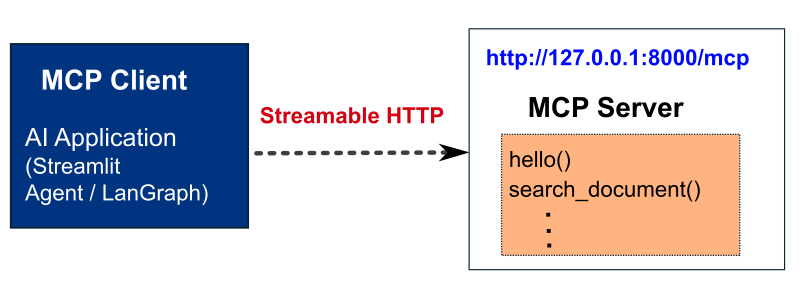

Here, `127.0.0.1` means the server is running on the **same computer** as the client. It is therefore a **local MCP server**, even though the communication uses HTTP.

**4. Server and Client Are Separate Processes**

A typical setup has two processes, Terminal 1 & Terminal 2:

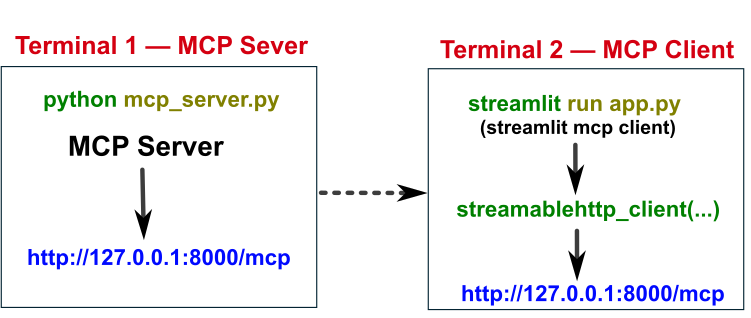

The important difference from `stdio` is that the MCP server is **started independently** and exposes an HTTP endpoint. The client then connects to that endpoint.



**Key takeaway**

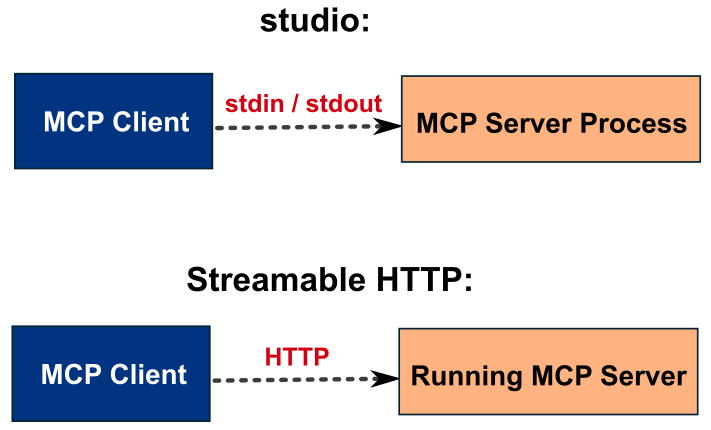


Streamable HTTP is particularly useful when the MCP server needs to be a **standalone service**, for example when it is running in Docker, serving multiple clients, or being accessed by applications such as Streamlit.

## Example 1 with Streamable HTTP 

The Example 1 run using `stdio` on last section, in this section run it with Streamable `HTTP`. To do this, `mcp.run(transport="stdio")` should be replaced with `mcp.run(transport="streamable-http")`

In [5]:
MCP_SERVER = f'''
from mcp.server.fastmcp import FastMCP
from langchain_community.utilities import SerpAPIWrapper
import os

mcp = FastMCP("Simple MCP Example")

# Register this function as a callable MCP tool.
@mcp.tool()
def multiply(a: float, b: float) -> int:
    """Multiply two float numbers"""
    return a * b

@mcp.tool()
def add(a: float, b: float) -> int:
    """Add two float numbers"""
    return a + b


@mcp.tool()
def google_search(query: str) -> str:
    """Apply Online Realtime Web Search"""
    serpapi = SerpAPIWrapper(serpapi_api_key="{os.getenv("SERP_API_KEY")}")
    return serpapi.run(query)

if __name__ == "__main__":
    mcp.run(transport="streamable-http")
'''

mcp_path = 'mcp_server_http_1.py'

with open(mcp_path, 'w') as f:
    f.write(MCP_SERVER)


First run this MCP Server in Terminal:

```bash
python mcp_server_http_1.py
```

MCP Server

    ↓
    
`127.0.0.1:8000/mcp`


![image.png](attachment:image.png)

After starting the MCP server, second run the following code to create an MCP client that connects to the server using Streamable HTTP.

The client connects to:

http://127.0.0.1:8000/mcp

It then:

- Establishes a connection with the MCP server.
- Initializes the MCP session.
- Retrieves and displays the available MCP tools.

In [9]:
import asyncio
from mcp import ClientSession
from mcp.client.streamable_http import streamable_http_client

async def main():

    async with streamable_http_client(
        "http://127.0.0.1:8000/mcp"
    ) as (read_stream, write_stream, _):

        async with ClientSession(
            read_stream,
            write_stream
        ) as session:

            await session.initialize()

            tools = await session.list_tools()

            print("\nAvailable tools:")
            for tool in tools.tools:
                print("-", tool.name)

            result = await session.call_tool(
                "multiply",
                arguments={
                    "a": 10,
                    "b": 5
                }
            )

            print("\nMultiply result:")
            print(result)


if __name__ == "__main__":
    await main()

[09/26/26 08:51:58] INFO     HTTP Request: POST http://127.0.0.1:8000/mcp "HTTP/1.1 200 OK"         ]8;id=469276;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=905586;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1786\1786]8;;\

                    INFO     Received session ID: 35fe1519abb74135976b505de30e4a9d           ]8;id=883973;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\mcp\client\streamable_http.py\streamable_http.py]8;;\:]8;id=454523;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\mcp\client\streamable_http.py#181\181]8;;\

                    INFO     Negotiated protocol version: 2025-11-25                         ]8;id=977064;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\mcp\client\streamable_http.py\streamable_http.py]8;;\:]8;id=751320;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\mcp\client\streamable_http.py#193\193]8;;\

                    INFO     HTTP Request: POST http://127.0.0.1:8000/mcp "HTTP/1.1 202 Accepted"   ]8;id=400604;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=195310;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1786\1786]8;;\

                    INFO     HTTP Request: GET http://127.0.0.1:8000/mcp "HTTP/1.1 200 OK"          ]8;id=491077;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=890859;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1786\1786]8;;\

                    INFO     HTTP Request: POST http://127.0.0.1:8000/mcp "HTTP/1.1 200 OK"         ]8;id=86011;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=975725;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1786\1786]8;;\


Available tools:
- multiply
- add
- google_search


                    INFO     HTTP Request: POST http://127.0.0.1:8000/mcp "HTTP/1.1 200 OK"         ]8;id=769167;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=95281;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1786\1786]8;;\


Multiply result:
meta=None content=[TextContent(type='text', text='50.0', annotations=None, meta=None)] structuredContent={'result': 50} isError=False


                    INFO     HTTP Request: DELETE http://127.0.0.1:8000/mcp "HTTP/1.1 200 OK"       ]8;id=519996;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=560156;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1786\1786]8;;\

# Remote MCP Server

A remote MCP server is a cloud-hosted MCP server that lets **AI agents connect to external tools** and data over the internet using HTTP-based communication, instead of running locally on your computer. It acts like a standardized bridge between LLMs and services such as GitHub, databases, Slack, or cloud platforms. Remote MCP servers simplify integrations because clients can securely access tools through one common protocol rather than building custom APIs for every service.

Here is list of curated list of high quality remote MCP servers: https://mcpservers.org/remote-mcp-servers

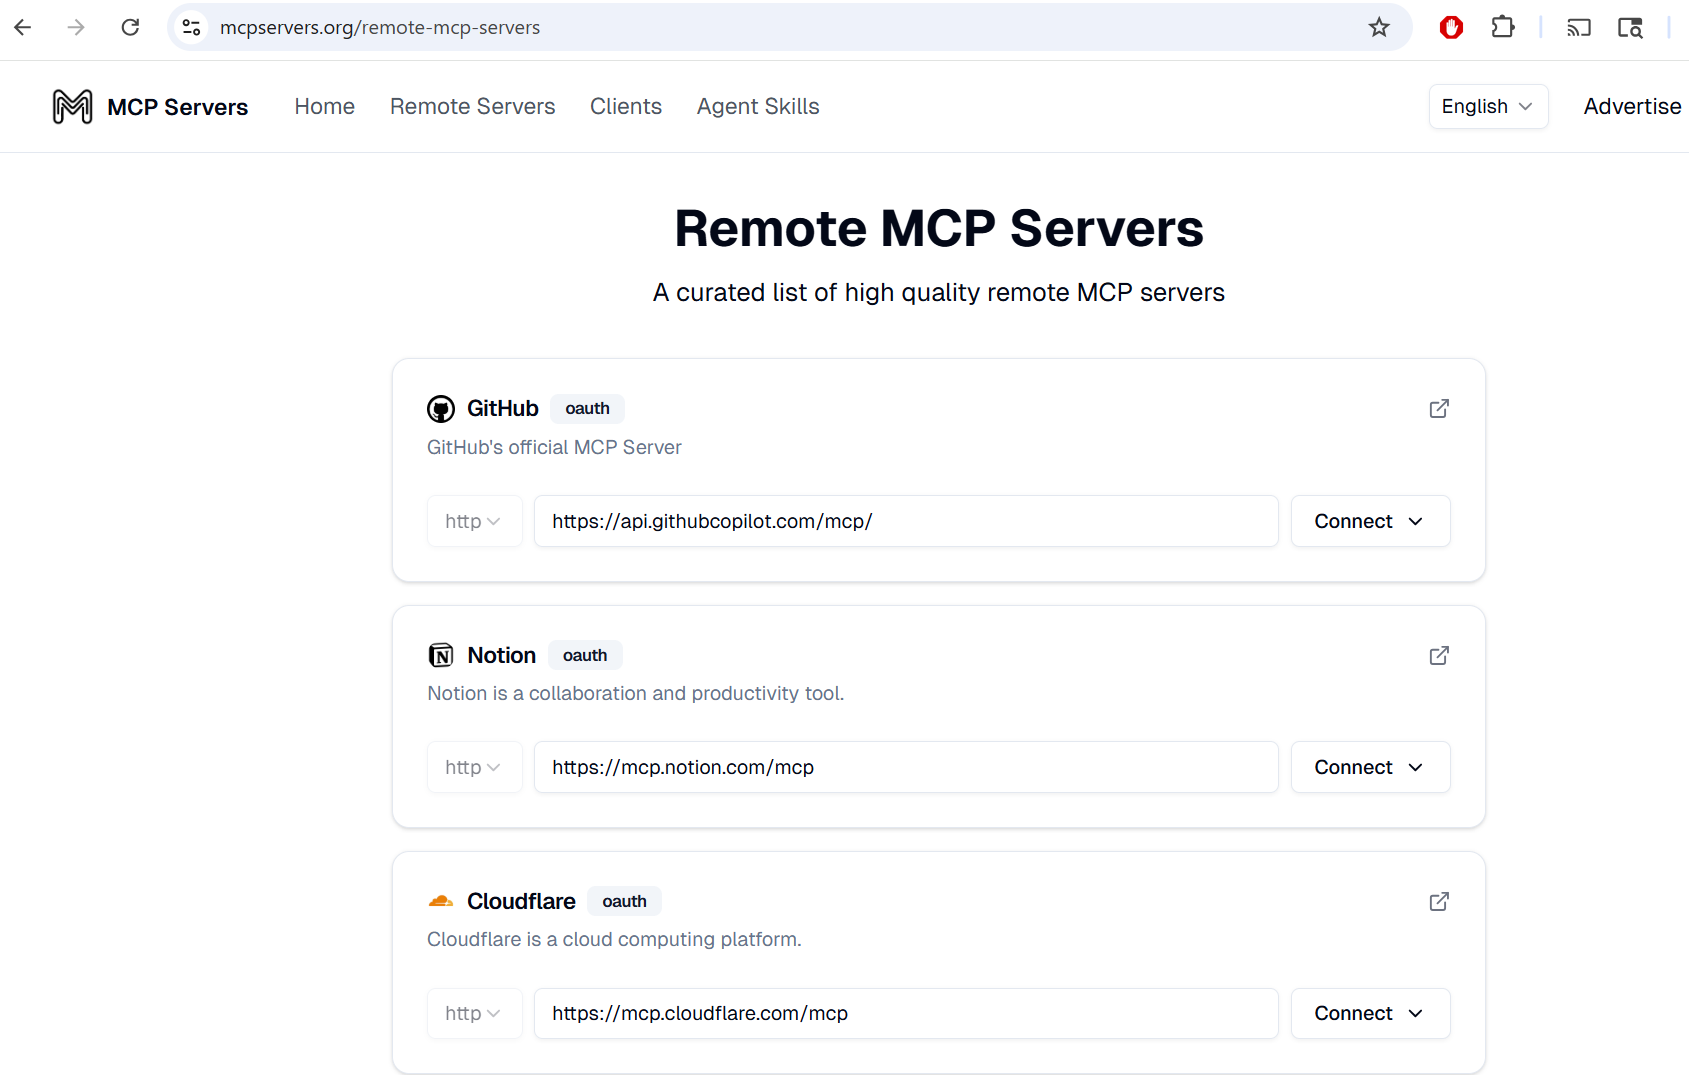

## Example : DeepWiki MCP Server

The function below initializes an MCP client session to connect to a remote MCP server **DeepWiki MCP Server** https://mcp.deepwiki.com/ and discover available tools on https://deepwiki.com/. It dynamically wraps each discovered MCP tool into a LangChain StructuredTool, then builds an agent (create_agent) that can use those tools with an LLM. Finally, it prints the registered tool metadata (name, schema, etc.) to confirm the agent is ready.

In [19]:
from langchain_core.tools import StructuredTool
# Make MCP connection call only once
from mcp import ClientSession
from mcp.client.streamable_http import streamablehttp_client

from langchain_core.tools import StructuredTool
from langchain.agents import create_agent

from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

mcp_ctx = None
session_ctx = None
session = None
agent = None


async def startup():

    global mcp_ctx
    global session_ctx
    global session
    global agent

    # =========================================================
    # CONNECT TO REMOTE MCP SERVER
    # =========================================================

    mcp_ctx = streamablehttp_client(
        "https://mcp.deepwiki.com/mcp"
    )

    read_stream, write_stream, _ = await mcp_ctx.__aenter__()

    # =========================================================
    # CREATE MCP SESSION
    # =========================================================

    session_ctx = ClientSession(
        read_stream,
        write_stream
    )

    session = await session_ctx.__aenter__()

    # =========================================================
    # INITIALIZE MCP SESSION
    # =========================================================

    await session.initialize()

    # =========================================================
    # GET REMOTE MCP TOOLS
    # =========================================================

    tools_response = await session.list_tools()

    print("\n===== REMOTE MCP TOOLS =====")

    for tool in tools_response.tools:

        print(f"\nTool: {tool.name}")
        print(f"Description: {tool.description}")
        print(f"Input schema: {tool.inputSchema}")

    # =========================================================
    # CONVERT MCP TOOLS TO LANGCHAIN TOOLS
    # =========================================================

    mcp_tools = await load_mcp_tools(session)

    print("\n===== LANGCHAIN MCP TOOLS =====")

    for tool in mcp_tools:

        print(f"\nTool name: {tool.name}")
        print(f"Description: {tool.description}")
        print(f"Arguments schema: {tool.args_schema}")

    # =========================================================
    # CREATE AGENT
    # =========================================================

    agent = create_agent(
        model=model,
        tools=mcp_tools,
        checkpointer=memory,
    )

    print("\nMCP Agent Ready")


await startup()

[09/21/26 20:58:07] INFO     HTTP Request: POST https://mcp.deepwiki.com/mcp "HTTP/1.1 200 OK"      ]8;id=582043;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=622714;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1786\1786]8;;\

                    INFO     Negotiated protocol version: 2025-11-25                         ]8;id=282241;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\mcp\client\streamable_http.py\streamable_http.py]8;;\:]8;id=891699;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\mcp\client\streamable_http.py#193\193]8;;\

                    INFO     HTTP Request: POST https://mcp.deepwiki.com/mcp "HTTP/1.1 202          ]8;id=5964;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=789444;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1786\1786]8;;\
                             Accepted"                                                                             

                    INFO     HTTP Request: POST https://mcp.deepwiki.com/mcp "HTTP/1.1 200 OK"      ]8;id=259234;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=571194;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1786\1786]8;;\


===== REMOTE MCP TOOLS =====

Tool: ask_wiki_question
Description: Ask any question about a GitHub repository's codebase and get an AI-powered answer
grounded in its DeepWiki.
Input schema: {'properties': {'repoName': {'anyOf': [{'type': 'string'}, {'items': {'type': 'string'}, 'type': 'array'}], 'description': 'GitHub repository or list of repositories (max 10) in owner/repo format.'}, 'question': {'description': 'The question to ask about the repository.', 'type': 'string'}}, 'required': ['repoName', 'question'], 'type': 'object'}

Tool: read_wiki_contents
Description: View documentation about a GitHub repository.
Input schema: {'properties': {'repoName': {'description': 'GitHub repository in owner/repo format (e.g. "facebook/react").', 'type': 'string'}}, 'required': ['repoName'], 'type': 'object'}

Tool: read_wiki_structure
Description: Get a list of documentation topics for a GitHub repository.
Input schema: {'properties': {'repoName': {'description': 'GitHub repository in owner/

                    INFO     HTTP Request: POST https://mcp.deepwiki.com/mcp "HTTP/1.1 200 OK"      ]8;id=52320;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=507718;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1786\1786]8;;\


===== LANGCHAIN MCP TOOLS =====

Tool name: ask_wiki_question
Description: Ask any question about a GitHub repository's codebase and get an AI-powered answer
grounded in its DeepWiki.
Arguments schema: {'properties': {'repoName': {'anyOf': [{'type': 'string'}, {'items': {'type': 'string'}, 'type': 'array'}], 'description': 'GitHub repository or list of repositories (max 10) in owner/repo format.'}, 'question': {'description': 'The question to ask about the repository.', 'type': 'string'}}, 'required': ['repoName', 'question'], 'type': 'object'}

Tool name: read_wiki_contents
Description: View documentation about a GitHub repository.
Arguments schema: {'properties': {'repoName': {'description': 'GitHub repository in owner/repo format (e.g. "facebook/react").', 'type': 'string'}}, 'required': ['repoName'], 'type': 'object'}

Tool name: read_wiki_structure
Description: Get a list of documentation topics for a GitHub repository.
Arguments schema: {'properties': {'repoName': {'description'

In [20]:
async def agent_run_async(message, thread_id="default"):
    return await agent.ainvoke(
        {"messages": [{"role": "user", "content": message}]},
        config={"configurable": {"thread_id": thread_id}}
    )

As can be seen, the DeepWiki MCP server offers three main tools:

1. **`read_wiki_structure`** - Get a list of documentation topics for a GitHub repository 
2. **`read_wiki_contents`** - View documentation about a GitHub repository 
3. **`ask_question`** - Ask any question about a GitHub repository and get an AI-powered, context-grounded response

In [21]:
query = """
Use this GitHub repository:

langchain-ai/langgraph

Return only:

1. Give link of GitHub repository to read and try basic concept of LangGraph.
2. The total number of documentation topics.
3. The name of each topic.

Keep the response very short.

"""

agent_response = await agent_run_async(
    query,
    thread_id="mcp_test_2"
)

[09/21/26 20:58:08] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=925501;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=801619;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1786\1786]8;;\
                             "HTTP/1.1 200 OK"                                                                     

                    INFO     HTTP Request: POST https://mcp.deepwiki.com/mcp "HTTP/1.1 200 OK"      ]8;id=215910;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=166685;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1786\1786]8;;\

                    INFO     HTTP Request: POST https://mcp.deepwiki.com/mcp "HTTP/1.1 200 OK"      ]8;id=280060;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=824825;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1786\1786]8;;\

[09/21/26 20:58:20] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=805548;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=364983;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1786\1786]8;;\
                             "HTTP/1.1 200 OK"                                                                     

In [22]:
# Last message
Markdown(agent_response["messages"][-1].content)

 1 ]8;id=439907;https://github.com/langchain-ai/langgraph\LangGraph GitHub Repository]8;;\                                                                                     
 2 Total number of documentation topics: 10                                                                        
 3 Names of each topic:                                                                                            
    • Overview                                                                                                     
    • Package Structure and Dependencies                                                                           
    • Core Execution System                                                                                        
    • Persistence and Memory                                                                                       
    • Client SDKs and Remote Execution                                                                             
    • CLI and Deployment                                                                                           
    • Server API                                                                                                   
    • Prebuilt Components                                                                                          
    • Development Infrastructure                                                                                   
    • Glossary

In [23]:
used_tools = set()

for msg in agent_response["messages"]:
    if hasattr(msg, "tool_calls") and msg.tool_calls:
        for tc in msg.tool_calls:
            used_tools.add(tc["name"])
            
if used_tools:
    for tool in sorted(used_tools):
        print(f"- 🛠️ {tool}")

- 🛠️ ask_wiki_question
- 🛠️ read_wiki_structure


Another question for Streamlit:

In [24]:
query = """
Use this GitHub repository:

streamlit/streamlit

What is Streamlit, and what are its three main features? give the link

Keep the answer very short.
"""

agent_response = await agent_run_async(
    query,
    thread_id="streamlit_test"
)

[09/21/26 20:58:21] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=997323;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=967624;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1786\1786]8;;\
                             "HTTP/1.1 200 OK"                                                                     

                    INFO     HTTP Request: POST https://mcp.deepwiki.com/mcp "HTTP/1.1 200 OK"      ]8;id=286504;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=214721;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1786\1786]8;;\

                    INFO     HTTP Request: POST https://mcp.deepwiki.com/mcp "HTTP/1.1 200 OK"      ]8;id=551940;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=585638;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1786\1786]8;;\

[09/21/26 20:58:35] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=6319;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=337501;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1786\1786]8;;\
                             "HTTP/1.1 200 OK"                                                                     

In [25]:
# Last message
Markdown(agent_response["messages"][-1].content)

Streamlit is an open-source Python library that allows you to transform Python scripts into interactive web        
applications quickly and easily.                                                                                   

                                               Three Main Features:                                                

 1 Simple and Pythonic: Build apps using standard Python code with an intuitive API.                               
 2 Fast, Interactive Prototyping: Rapid development and iteration, enabling quick feedback from data interactions. 
 3 Live Editing and Real-time Updates: Changes in the script instantly reflect in the web application.             

For more details, you can check the Streamlit GitHub wiki ]8;id=864250;https://github.com/streamlit/streamlit/wiki\here]8;;\.

The personal github pages should be indexed https://deepwiki.com, otherwise it cannot be found in Deepwiki MCP server:
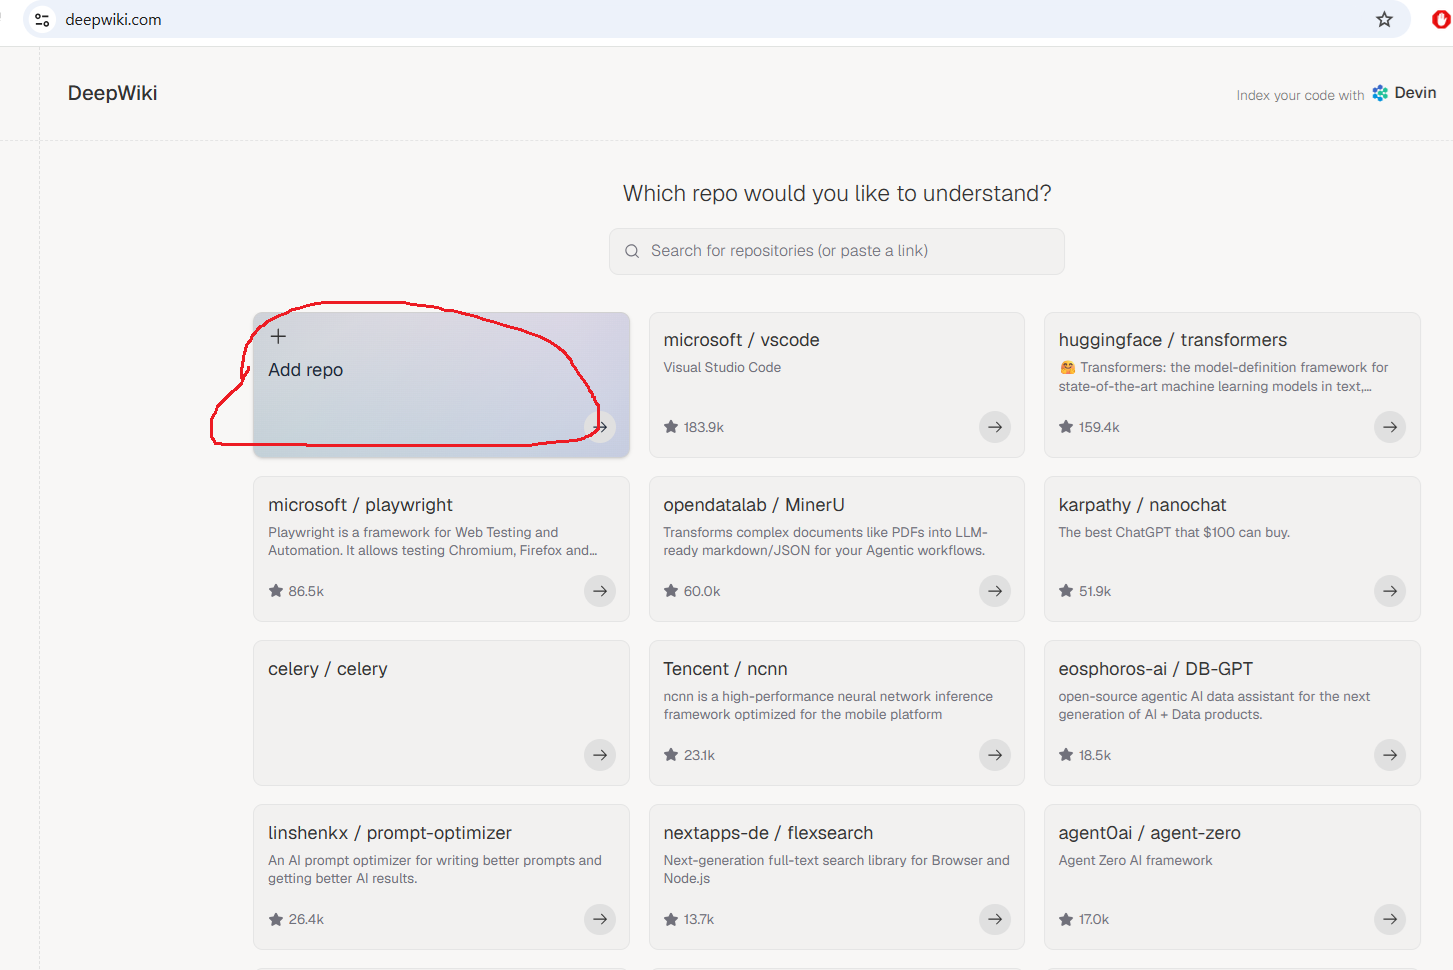

In [26]:
query = """
Use this GitHub repository:

MehdiRezvandehy/Machine-Learning-Course-University-of-Calgary

How many documentation topics are available?
Give very short description (1-2 sentences) for each notebook with the link of the notebook
"""

agent_response = await agent_run_async(
    query,
    thread_id="personal_repo"
)

[09/21/26 20:58:36] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=29037;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=53982;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1786\1786]8;;\
                             "HTTP/1.1 200 OK"                                                                     

                    INFO     HTTP Request: POST https://mcp.deepwiki.com/mcp "HTTP/1.1 200 OK"      ]8;id=724378;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=669002;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1786\1786]8;;\

[09/21/26 20:58:37] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=272760;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=140860;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1786\1786]8;;\
                             "HTTP/1.1 200 OK"                                                                     

                    INFO     HTTP Request: POST https://mcp.deepwiki.com/mcp "HTTP/1.1 200 OK"      ]8;id=43732;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=14181;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1786\1786]8;;\

[09/21/26 20:58:47] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=250776;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=65139;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1786\1786]8;;\
                             "HTTP/1.1 200 OK"                                                                     

In [27]:
# Last message
Markdown(agent_response["messages"][-1].content)

The GitHub repository "MehdiRezvandehy/Machine-Learning-Course-University-of-Calgary" has multiple documentation   
topics available. Here's a summary of the sections and a brief description of each notebook with links:            

                                            Total Documentation Topics                                             

There are 10 main documentation topics available in the repository.                                                

                                                Notebook Summaries                                                 

  1 ]8;id=274271;#1\Course Overview]8;;\:                                                                                               
     • Provides an overview of the course objectives, structure, and resources.                                    
  2 ]8;id=257458;#2\Python and Data Foundations]8;;\:                                                                                   
     • Covers the basics of Python programming and the Pandas library for data manipulation.                       
     • Includes:                                                                                                   
        • ]8;id=861430;##2.1\Machine Learning Overview (Class 01)]8;;\: Fundamental definitions of Machine Learning.                       
        • ]8;id=198801;##2.2\Python Programming Basics (Classes 02 & Python Install)]8;;\: Core Python concepts.                           
        • ]8;id=140252;##2.3\Pandas for Data Manipulation (Class 03)]8;;\: Data structures and operations in Pandas.                       
        • ]8;id=224941;##2.4\Main Steps of a Machine Learning Project (Class 04)]8;;\: Overview of the ML pipeline.                        
  3 ]8;id=677501;#3\Supervised Learning]8;;\:                                                                                           
     • Discusses various supervised learning techniques including classification and regression methods, covering: 
        • ]8;id=292257;##3.1\Classification (Class 05)]8;;\: Introduction to classification algorithms and performance metrics.            
        • ]8;id=50896;##3.2\Model Training and Optimisation (Class 06)]8;;\: Techniques for training models and optimising parameters.    
        • ]8;id=418830;##3.3\Support Vector Machines (Class 07)]8;;\: Details the SVM algorithm for classification.                        
        • ]8;id=947180;##3.4\Decision Trees (Class 08)]8;;\: Overview of decision trees and their application.                             
        • ]8;id=824423;##3.5\Ensemble Learning and Random Forests (Class 09)]8;;\: Focuses on ensemble methods for improving model         
          performance.                                                                                             
  4 ]8;id=677057;#4\Neural Networks and Deep Learning]8;;\:                                                                             
     • Discusses the architecture and training of neural networks, covering:                                       
        • ]8;id=420009;##4.1\Artificial Neural Networks (Class 10)]8;;\: Basics of artificial neurons and their implementation.            
        • ]8;id=629127;##4.2\Deep Neural Networks and Deep Learning (Class 11)]8;;\: Builds on ANN to cover deeper architectures and       
          techniques.                                                                                              
  5 ]8;id=35837;##5\Unsupervised Learning (Class 12)]8;;\:                                                                              
     • Covers dimensionality reduction techniques (like PCA) and clustering methods (like K-Means and DBSCAN).     
  6 ]8;id=84352;#6\Software Engineering for Data Scientists]8;;\:                                                                      
     • Discusses best practices in coding for data science, 

# 📚 Document Intelligence App: MCP, RAG, and AI Agents

I developed an AI-powered document intelligence application that
applies **Model Context Protocol (MCP)** for both local and remote MCP server, **Retrieval-Augmented Generation (RAG)**,
and **AI agents** using Streamlit:

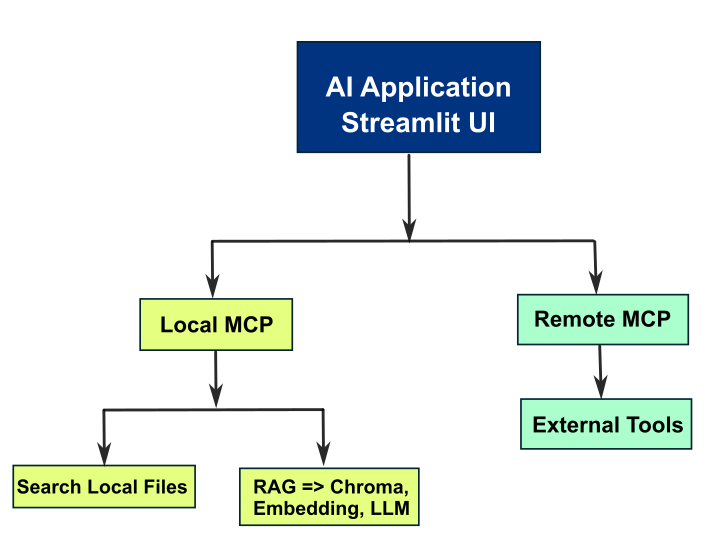

The application provides three main capabilities:

## 🔍 **Local MCP — Drive Search**

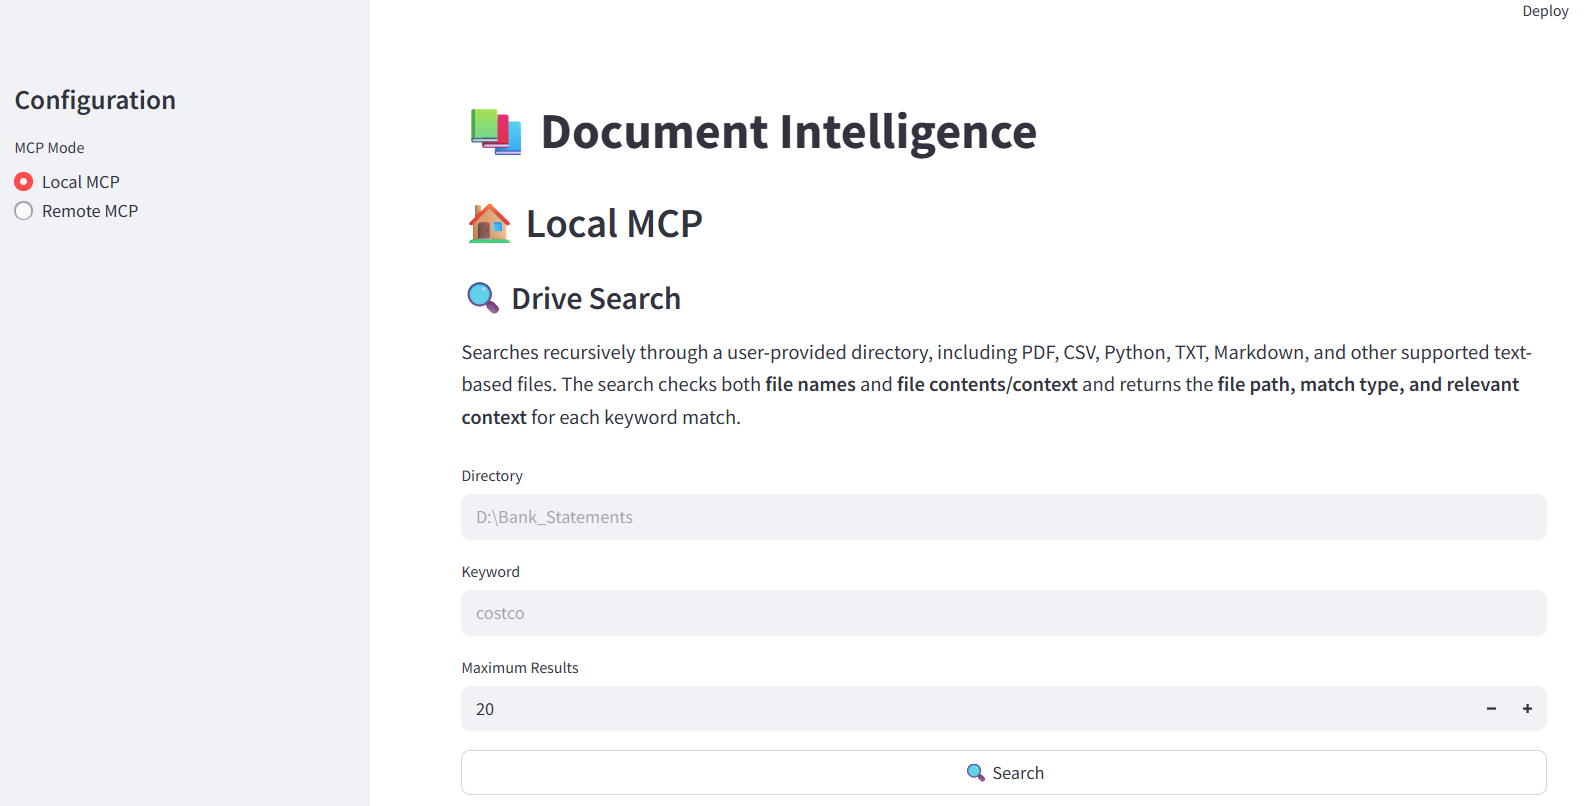

The first capability provides a simple way to search documents stored on a
local drive.

The user provides:

- A directory
- A search keyword
- A maximum number of results

The MCP server recursively searches the directory and examines supported
document types such as:

- PDF
- Word (`.docx`)
- Excel (`.xlsx`, `.xlsm`)
- CSV
- TXT
- Markdown
- Python and other source-code files
- JSON
- Jupyter Notebooks

The search is performed in two ways:

**1. File-name search**

    The keyword is searched in the file name.

**2. Content search**

    The keyword is searched inside the document content. For content matches, the MCP server returns a section of surrounding text as context.

## 🤖 **Local RAG for Document Question Answering**
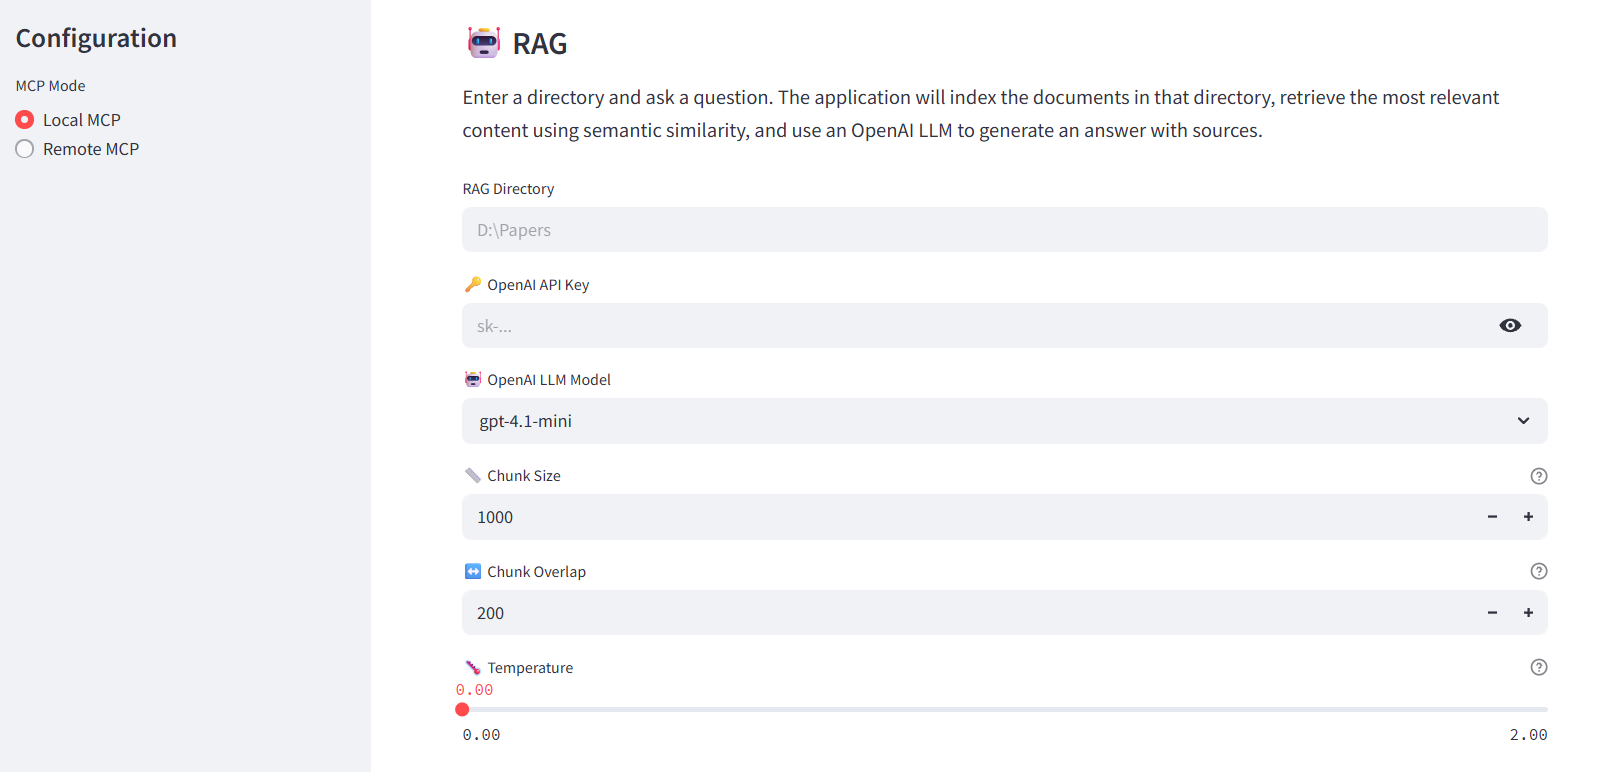

The second capability uses Retrieval-Augmented Generation (**RAG**) to answer
questions using documents stored on the local drive.

Unlike keyword search, RAG does not require the question to contain the exact
words appearing in the document.

For example, a document may contain:

> "The total amount payable is $245.67."

The user could ask:

> "How much do I need to pay?"

Semantic retrieval can identify the relevant section even though the words
"how much" and "pay" may not appear exactly in the document.

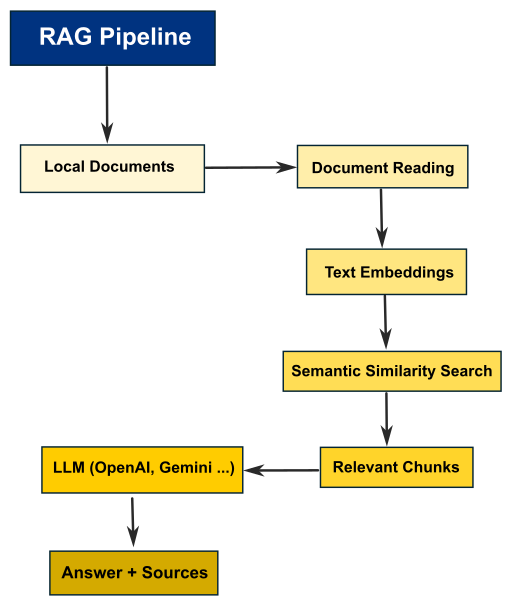

## 🌐 **Remote MCP Agent**
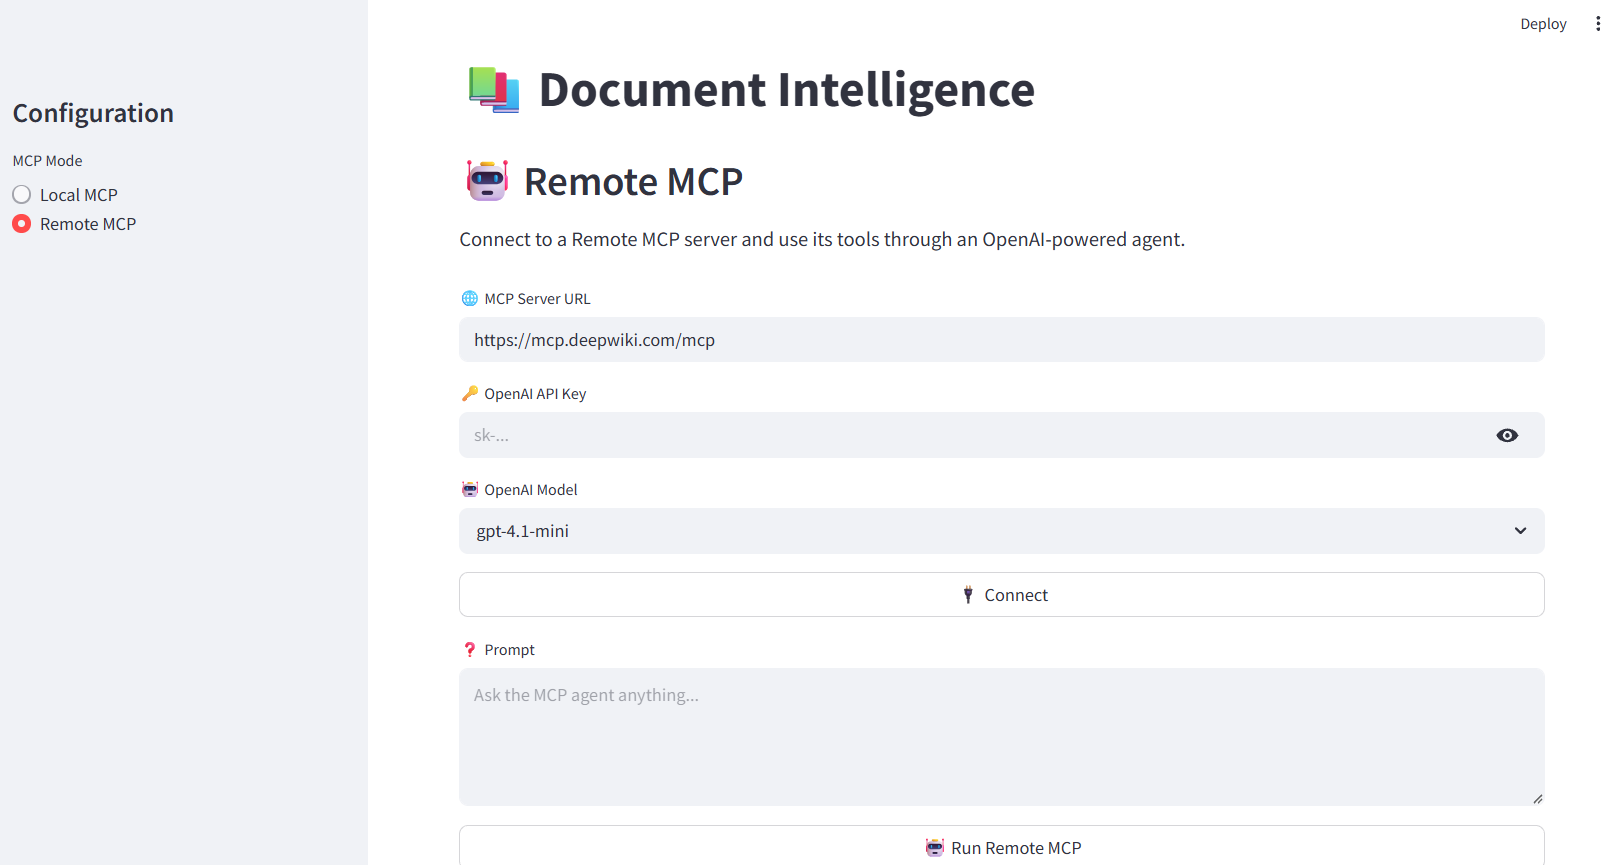

The third capability demonstrates how an AI agent can use tools exposed by a
remote MCP server.

Instead of implementing every tool locally, the application connects to an
MCP server through its MCP endpoint.

For example, the application can connect to:

`https://mcp.deepwiki.com/mcp`

The remote server exposes a set of tools that the agent can use.

Here is the workflow:
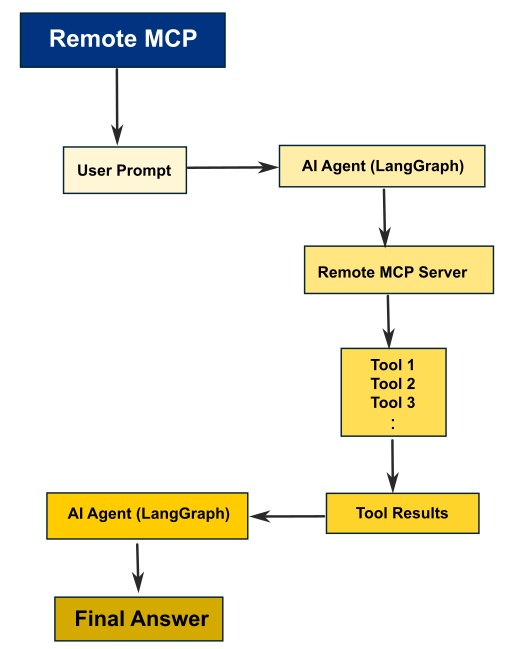

## Implementation

This application is implemented with **Streamlit** and is deployed using
**Docker Compose**.

The application is containerized into separate services:
```text
Docker
  │
  ├── Streamlit Application
  │
  └── Local MCP Server
          │
          └── Docker Network
```
When using Docker Compose, Docker automatically creates a network for the services defined in the Compose file. This network allows the containers to communicate with each other using their service names.

For example, the Streamlit container can connect to the MCP server using:

`http://mcp-server:8000/mcp`

rather than:

`http://127.0.0.1:8000/mcp`

The reason is that `127.0.0.1` always refers to the current container itself. Therefore, from inside the Streamlit container, `127.0.0.1:8000` points to the Streamlit container, not the MCP server container.

So, when both services are running under Docker Compose:
 
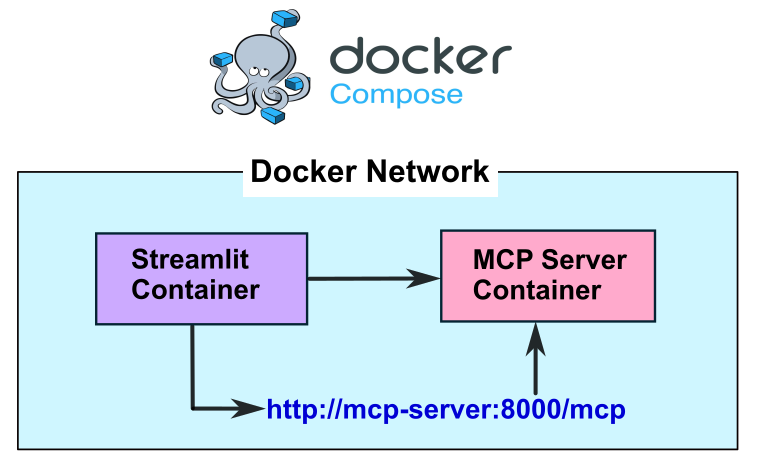

### `document_search_mcp.py`

The code `document_search_mcp.py`:

* **Creates an MCP server** called `"Document Search MCP"` using FastMCP. 
* **Defines supported files**:

  * Text/code: `.txt`, `.md`, `.py`, `.js`, `.json`, `.csv`, `.sql`, etc.
  * Documents: `.pdf`, `.docx`
  * Excel: `.xlsx`, `.xlsm`
  * Jupyter notebooks: `.ipynb` 
* **Ignores unnecessary directories** such as `.git`, `.venv`, `node_modules`, `.vscode`, etc. 


It has separate readers:

* **PDF** → extracts text page by page and adds `[PAGE n]`
* **DOCX** → extracts paragraphs and tables
* **Excel** → extracts sheet names and cell values
* **IPYNB** → extracts each notebook cell and adds `[CELL n]`
* **Text/code files** → simply reads the text content  

The main MCP tool is `search_documents` in `document_search_mcp.py`

```python
# MCP SEARCH TOOL
@mcp.tool()
def search_documents(
    directory: str,
    query: str,
    max_results: int = 20,
) -> str:
```

so an MCP client can discover and call `search_documents`. It does **traditional keyword search**, not an embedding/vector/RAG search.

Now the question is how the search works

For example, if the query is:

```text
machine learning
```

It first checks whether `"machine learning"` appears in the **filename**. Then it checks whether the exact phrase appears in the **file content**. 

When it finds a content match, it returns approximately **1,000 characters before and after the match** as context. 




The flow is:
![image.png](attachment:image.png)

The final response is JSON containing:

```text
file
file_name
file_type
match_type
context
```

**How it becomes an MCP server**

   When we run the `document_search_mcp.py` Python file, it starts the server by:
   
   ```python
      if __name__ == "__main__":
          mcp.settings.host = "0.0.0.0"
          mcp.settings.port = 8000
      
          mcp.run(
              transport="streamable-http"
          )
   ```
   
The MCP server exposes this search functionality over **Streamable HTTP**. 
   
**In one sentence:**

`document_search_mcp.py` is an MCP server that exposes a `search_documents` tool, which recursively scans a directory, reads many document types, performs **keyword-based filename/content search**, extracts surrounding context, and returns the results as JSON.
   
   

### Dockerfile.mcp

Here is `Dockerfile.mcp` that runs the `document_search_mcp.py` inside docker :

```dockerfile
FROM python:3.11-slim

WORKDIR /app

RUN apt-get update && apt-get install -y \
    build-essential \
    && rm -rf /var/lib/apt/lists/*

COPY requirements.txt .

RUN pip install --no-cache-dir -r requirements.txt

COPY document_search_mcp.py .

EXPOSE 8000

CMD ["python", "document_search_mcp.py"]
```


Overall flow is:
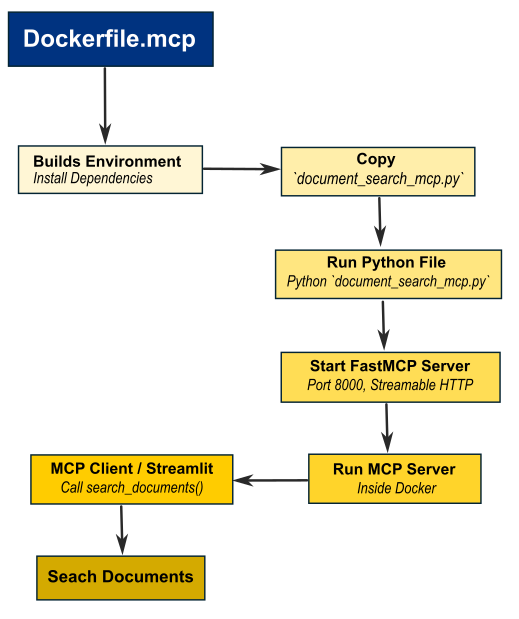

The `EXPOSE 8000` instruction in `Dockerfile.mcp` indicates that the application inside the container is expected to use **port 8000**.

This matches the port configured in `document_search_mcp.py`:

```python
mcp.settings.port = 8000
```

The script then starts the MCP server with:

```python
if __name__ == "__main__":
    mcp.settings.host = "0.0.0.0"
    mcp.settings.port = 8000

    mcp.run(
        transport="streamable-http"
    )
```

Therefore, when the container starts:

1. Docker runs `python document_search_mcp.py`.
2. The Python script starts the MCP server.
3. The server listens on **0.0.0.0:8000** inside the container.
4. `EXPOSE 8000` documents that the application uses port **8000**.
5. Docker Compose can then map the container port to a host port.

For example, with:

```yaml
ports:
  - "8000:8000"
```

the MCP server becomes accessible from the host at:

```text
http://localhost:8000
```


## 🔍 Local MCP — Drive Search

The first capability provides a simple way to search documents stored on a
local drive.

The user provides:

- A directory
- A search keyword
- A maximum number of results

The MCP server recursively searches the directory and examines supported
document types such as:

- PDF
- Word (`.docx`)
- Excel (`.xlsx`, `.xlsm`)
- CSV
- TXT
- Markdown
- Python and other source-code files
- JSON
- Jupyter Notebooks

The search is performed in two ways:

**File-name search**

The keyword is searched in the file name.

**Content search**

The keyword is searched inside the document content.

For content matches, the MCP server returns a section of surrounding text
as context.

**Workflow**

```text
User
 │
 │ Directory + Keyword
 ▼
Streamlit
 │
 │ MCP request
 ▼
Local MCP Server
 │
 ├── Recursively scan directories
 ├── Identify supported files
 ├── Search file names
 └── Search file contents
 │
 ▼
Search Results
 │
 ├── File name
 ├── File path
 ├── Match type
 └── Matching context
 ```

**Why MCP?**

Instead of implementing the document-search functionality directly inside the Streamlit application, the search capability is exposed as an **MCP tool**.

This separates the **application interface** from the **document-search capability**.

The Streamlit application acts as the client, while the **MCP server provides
the document-search tool.**


---

## 🤖 Local RAG — Document Question Answering

The second capability uses Retrieval-Augmented Generation (RAG) to answer
questions using documents stored on the local drive.

Unlike keyword search, RAG does not require the question to contain the exact
words appearing in the document.

For example, a document may contain:

> "The total amount payable is $245.67."

The user could ask:

> "How much do I need to pay?"

Semantic retrieval can identify the relevant section even though the words
"how much" and "pay" may not appear exactly in the document.


**RAG Pipeline**

```text
Local Documents
      │
      ▼
Document Reading
      │
      ▼
Text Chunking
      │
      ▼
OpenAI Embeddings
      │
      ▼
Chroma Vector Database
      │
      ▼
Semantic Similarity Search
      │
      ▼
Relevant Chunks
      │
      ▼
OpenAI LLM
      │
      ▼
Answer + Sources
```

## 🌐 Remote MCP Agent



There are **two containers**:

1. **Streamlit container**
   * app.py
   * Local MCP client
   * RAG code
   * Remote MCP Agent
   * OpenAI connection
2. **Local MCP container**
   * Your document_search_mcp.py
   * Searches the mounted host directory

And Docker Compose connects them.

# Summary

## Risk Using MCP

MCP is a powerful idea, but it is not without risks. For example, some MCP servers could potentially be misused to access sensitive or private information. However, this is not a flaw in MCP itself, nor is it a fault of platforms like GitHub. Rather, it reflects a broader challenge in how LLMs are granted access to external tools and how those tools are composed and chained together.

In many cases, security issues arise when tool access is not carefully scoped, and when combinations of tools can be orchestrated in unintended or malicious ways. For instance, there have been scenarios where an LLM, through a GitHub MCP integration, was able to interact with repositories it should not have had access to.

The key point is that everything in this stack has potential vulnerabilities—LLMs, MCP servers, and tool integrations. MCP itself is simply a standard for structuring and unifying tool calling in LLM systems. It does not inherently introduce the problem; rather, it defines a mechanism that can be misused if the underlying access controls and model behavior are not properly constrained.

In this sense, **the issue is less about MCP as a protocol and more about how LLMs interpret and execute tool usage in potentially adversarial contexts.**

From the LLM’s perspective, **nothing has fundamentally changed**. It is still operating as a standard tool-calling model, interacting through human messages, AI messages, and tool messages exactly as before. The agent itself does not care whether an MCP server is running in the background. To the LLM, tools simply appear in the prompt, and it decides which tool to call.

The only real difference is **where the tool execution happens**. Instead of running locally or inside the application, the request is routed through an **MCP server**. For example, the LLM may decide to call a tool, LangGraph or LangChain converts that request into an MCP call, the **MCP server executes the tool**, and the result is returned back to the agent as a tool message. **From the LLM’s perspective, the workflow remains unchanged.**

Because of this, whether or not we use an MCP server is primarily a **development and architecture choice**. It does not change the LLM’s tool-calling capabilities, and it is irrelevant when evaluating whether the model itself can effectively use tools.

What MCP changes is the infrastructure layer. MCP provides a **standardized way to expose, share, and manage tools, prompts, and resources** across systems and organizations. While it still has limitations and evolving standards, it is becoming an important foundation for building interoperable AI agents and enabling collaboration between different applications and ecosystems.